## Step 1 — Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 999)
data_dir = "/Users/ziqiwei/Downloads"

# M = men's, W = women's
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

In [ ]:
# stack men's and women's into one dataframe
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [ ]:
season = 2003  # data starts here; bump this up if you want a shorter training window
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

## Step 2 — Quick Look at the Data

In [7]:
regular_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85500,2026,93,3421,60,3149,48,A,0,20,56,5,13,15,24,9,33,8,11,0,0,23,14,58,5,21,15,21,4,22,8,7,4,5,22
85501,2026,93,3428,67,3416,57,A,0,24,57,10,25,9,10,6,27,15,17,10,2,16,20,59,5,14,12,16,11,22,10,15,6,7,11
85502,2026,93,3437,67,3139,57,A,0,27,64,6,20,7,8,7,19,14,6,11,3,13,23,49,4,15,7,10,5,22,11,16,5,2,10
85503,2026,93,3452,61,3160,55,A,0,24,58,7,18,6,11,6,23,7,14,11,3,19,19,53,2,9,15,19,9,27,9,17,8,3,14


In [8]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,6,25,16,12,10,2,17,19,58,3,13,23,26,13,29,7,15,8,2,18
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,11,23,14,8,9,6,20,12,45,4,20,19,21,11,27,8,21,1,3,14
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,9,25,17,7,13,2,16,20,52,4,16,7,8,8,21,11,19,5,2,12
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,10,26,17,13,7,5,15,22,56,4,10,9,12,9,20,10,14,6,5,17


In [ ]:
# track one team's full 2024 run — regular season + tournament
season = 2024
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

In [10]:
seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
1739,2025,Z12,3193
1740,2025,Z13,3251
1741,2025,Z14,3195
1742,2025,Z15,3117


In [ ]:
# seeds are split into 4 regions (W/X/Y/Z) — check the breakdown for one season
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

In [ ]:
# what seed did this team get?
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

## Step 3 — Data Prep

In [ ]:
# flip each game so it appears from both teams' perspectives
# this doubles the dataset and removes the W/L labeling bias
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]

    # OT games accumulate more stats — normalize everything to 40-minute equivalent
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [14]:
regular_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416555,2026,93,3421,60.0,3149,48.0,0,20.0,56.0,5.0,13.0,15.0,24.0,9.0,33.0,8.0,11.0,0.0,0.0,23.0,14.0,58.0,5.0,21.0,15.0,21.0,4.0,22.0,8.0,7.0,4.0,5.0,22.0,-12.0,0,0
416556,2026,93,3428,67.0,3416,57.0,0,24.0,57.0,10.0,25.0,9.0,10.0,6.0,27.0,15.0,17.0,10.0,2.0,16.0,20.0,59.0,5.0,14.0,12.0,16.0,11.0,22.0,10.0,15.0,6.0,7.0,11.0,-10.0,0,0
416557,2026,93,3437,67.0,3139,57.0,0,27.0,64.0,6.0,20.0,7.0,8.0,7.0,19.0,14.0,6.0,11.0,3.0,13.0,23.0,49.0,4.0,15.0,7.0,10.0,5.0,22.0,11.0,16.0,5.0,2.0,10.0,-10.0,0,0
416558,2026,93,3452,61.0,3160,55.0,0,24.0,58.0,7.0,18.0,6.0,11.0,6.0,23.0,7.0,14.0,11.0,3.0,19.0,19.0,53.0,2.0,9.0,15.0,19.0,9.0,27.0,9.0,17.0,8.0,3.0,14.0,-6.0,0,0


In [15]:
tourney_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,134,1411,74.666667,1421,81.777778,1,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,7.111111,1,1
1,2003,136,1436,51.000000,1112,80.000000,0,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,29.000000,1,1
2,2003,136,1272,71.000000,1113,84.000000,0,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,13.000000,1,1
3,2003,136,1166,73.000000,1141,79.000000,0,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,6.000000,1,1
4,2003,136,1301,65.777778,1143,67.555556,1,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,1.777778,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4815,2025,147,3163,78.000000,3425,64.000000,0,27.000000,60.000000,10.000000,22.000000,14.000000,17.000000,6.000000,25.000000,16.000000,12.000000,10.000000,2.000000,17.000000,19.000000,58.000000,3.000000,13.000000,23.000000,26.000000,13.000000,29.000000,7.000000,15.000000,8.000000,2.000000,18.000000,-14.000000,0,0
4816,2025,147,3400,58.000000,3395,47.000000,0,24.000000,61.000000,2.000000,3.000000,8.000000,11.000000,11.000000,23.000000,14.000000,8.000000,9.000000,6.000000,20.000000,12.000000,45.000000,4.000000,20.000000,19.000000,21.000000,11.000000,27.000000,8.000000,21.000000,1.000000,3.000000,14.000000,-11.000000,0,0
4817,2025,151,3163,85.000000,3417,51.000000,0,33.000000,60.000000,7.000000,16.000000,12.000000,17.000000,9.000000,25.000000,17.000000,7.000000,13.000000,2.000000,16.000000,20.000000,52.000000,4.000000,16.000000,7.000000,8.000000,8.000000,21.000000,11.000000,19.000000,5.000000,2.000000,12.000000,-34.000000,0,0
4818,2025,151,3376,74.000000,3400,57.000000,0,29.000000,57.000000,7.000000,11.000000,9.000000,12.000000,10.000000,26.000000,17.000000,13.000000,7.000000,5.000000,15.000000,22.000000,56.000000,4.000000,10.000000,9.000000,12.000000,9.000000,20.000000,10.000000,14.000000,6.000000,5.000000,17.000000,-17.000000,0,0


In [ ]:
# sanity check — the same game should appear twice with flipped scores
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

## Features — Tier 1: Basic (Seed)

In [ ]:
# pull the seed number out of the string (e.g. "W01" → 1)
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

In [18]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


In [ ]:
# does seed predict point differential? plot it to find out
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

In [ ]:
# same thing but for seed difference between the two teams
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## Features — Tier 2: Season Stats

In [ ]:
# all the box score stats we want to aggregate into season averages
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

**The idea behind these features:**

For any matchup between **T1** and **T2**, we want to capture how each team performed throughout the regular season — not just their own stats, but also what their opponents tended to do against them.

Specifically, for each team **T** we compute two things:
- `average[T]` — T's own regular season averages (scoring, rebounding, etc.)
- `average[T_opponents]` — how T's opponents performed on average (measures defensive strength)

Then for a tournament game between T1 and T2, we attach both of these profiles for each side, giving the model a richer picture of the matchup than seed alone.

In [ ]:
# compute each team's regular season averages, then join to tourney matchups
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

In [ ]:
# FEATURE: Last-14-days win ratio
# Hot teams entering the tournament (DayNum > 118) tend to outperform their seed
late_season = regular_data.loc[regular_data["DayNum"] > 118].copy()
late_wins = late_season.groupby(["Season", "T1_TeamID"])["win"].agg(["sum", "count"]).reset_index()
late_wins.columns = ["Season", "TeamID", "late_wins", "late_games"]
late_wins["WinRatio14d"] = late_wins["late_wins"] / late_wins["late_games"]

late_T1 = late_wins.rename({"TeamID": "T1_TeamID", "WinRatio14d": "T1_WinRatio14d"}, axis=1)[["Season","T1_TeamID","T1_WinRatio14d"]]
late_T2 = late_wins.rename({"TeamID": "T2_TeamID", "WinRatio14d": "T2_WinRatio14d"}, axis=1)[["Season","T2_TeamID","T2_WinRatio14d"]]

tourney_data = pd.merge(tourney_data, late_T1, on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, late_T2, on=["Season","T2_TeamID"], how="left")

# FEATURE: Full-season win ratio
# Simple but effective baseline — complements the late-season form above
away_data = regular_data.loc[regular_data["T1_TeamID"].notna()].copy()

all_wins = regular_data.groupby(["Season","T1_TeamID"])["win"].agg(["sum","count"]).reset_index()
all_wins.columns = ["Season","TeamID","wins","games"]
all_wins["awins"] = all_wins["wins"] / all_wins["games"]

awins_T1 = all_wins.rename({"TeamID":"T1_TeamID","awins":"T1_awins"},axis=1)[["Season","T1_TeamID","T1_awins"]]
awins_T2 = all_wins.rename({"TeamID":"T2_TeamID","awins":"T2_awins"},axis=1)[["Season","T2_TeamID","T2_awins"]]

tourney_data = pd.merge(tourney_data, awins_T1, on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, awins_T2, on=["Season","T2_TeamID"], how="left")

# FEATURE: Head-to-head win rate (Laplace-smoothed)
# If the two teams have played before, that history matters
# Laplace smoothing (wins+1)/(games+2) prevents 0 or 1 extremes for rare matchups
h2h = {}
for _, row in regular_results.iterrows():
    key = (row["Season"], int(row["WTeamID"]), int(row["LTeamID"]))
    rkey = (row["Season"], int(row["LTeamID"]), int(row["WTeamID"]))
    h2h[key] = h2h.get(key, [0, 0])
    h2h[key][0] += 1; h2h[key][1] += 1
    h2h[rkey] = h2h.get(rkey, [0, 0])
    h2h[rkey][1] += 1

def laplace_matchup(season, t1, t2):
    key = (season, int(t1), int(t2))
    wins, games = h2h.get(key, [0, 0])
    return (wins + 1) / (games + 2)

tourney_data["laplace_matchup"] = tourney_data.apply(
    lambda r: laplace_matchup(r["Season"], r["T1_TeamID"], r["T2_TeamID"]), axis=1
)

print("New features added: T1_WinRatio14d, T2_WinRatio14d, T1_awins, T2_awins, laplace_matchup")
print(tourney_data[["T1_WinRatio14d","T2_WinRatio14d","T1_awins","T2_awins","laplace_matchup"]].describe())

## Features — Tier 3: ELO Rating

In [ ]:
def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo, k):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo

base_elo = 1000
elo_width = 400

def elo_fill(k):
    elos = []
    for season in sorted(set(seeds["Season"])):
        ss = regular_data.loc[regular_data["Season"] == season]
        ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
        teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
        elo = dict(zip(teams, [base_elo] * len(teams)))
        for i in range(ss.shape[0]):
            w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
            w_elo, l_elo = elo[w_team], elo[l_team]
            elo[w_team], elo[l_team] = update_elo(w_elo, l_elo, k)
        elo_df = pd.DataFrame.from_dict(elo, orient="index").reset_index()
        elo_df = elo_df.rename({"index": "TeamID", 0: "elo"}, axis=1)
        elo_df["Season"] = season
        elos.append(elo_df)
    return pd.concat(elos, ignore_index=True)

# Grid search for best k_factor
loss_dict = {}
for k in range(40, 161, 10):
    tourney_copy = tourney_data.copy()
    test = elo_fill(k)
    elos_T1 = test.rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
    elos_T2 = test.rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
    tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
    tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")
    tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])
    season_loss = []
    for season in tourney_copy["Season"].unique():
        sub = tourney_copy[tourney_copy["Season"] == season]
        # 用 win 列作为 target，同时覆盖 T1/T2 赢的场次（修复原始只计算 win==1 的 bug）
        season_loss.append(((sub["expect"] - sub["win"]) ** 2).mean())
    loss_dict[k] = float(np.mean(season_loss))

loss_df = (
    pd.DataFrame([{"k_factor": k, "mean_loss": v} for k, v in loss_dict.items()])
    .sort_values("mean_loss")
    .reset_index(drop=True)
)
print(loss_df)

best_k = int(loss_df.loc[0, "k_factor"])
best_loss = float(loss_df.loc[0, "mean_loss"])
print(f"best_k: {best_k},  best_loss: {best_loss:.5f}")

plot_df = loss_df.sort_values("k_factor")
plt.figure(figsize=(8, 4))
plt.plot(plot_df["k_factor"], plot_df["mean_loss"], marker="o")
plt.xlabel("k_factor")
plt.ylabel("Mean MSE Loss")
plt.title("Mean Loss vs K-factor")
plt.grid(True)
plt.tight_layout()
plt.show()

# 用最优 k 生成最终 ELO，合并进 tourney_data
elos = elo_fill(best_k)
elos_T1 = elos.rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]


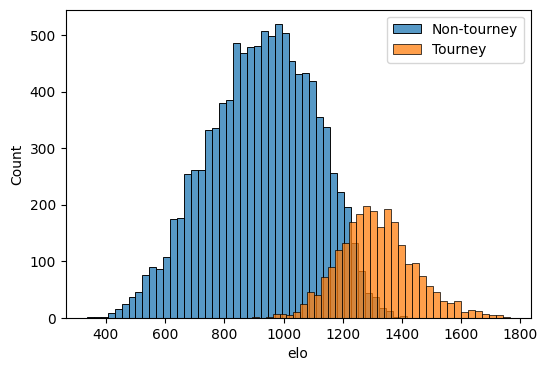

In [24]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.histplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False, label='Non-tourney')
seaborn.histplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False, label='Tourney')
plt.legend()

## Features — Tier 4: Massey Ordinals (Men's)

In [ ]:
# Load Massey Ordinals (men's only, available from 2003)
massey = pd.read_csv(f"{data_dir}/MMasseyOrdinals.csv")

# Keep only pre-tournament rankings (tournament starts ~DayNum 134)
massey_pre = massey[massey["RankingDayNum"] <= 133].copy()

# For each season, find the last ranking day available
last_day = massey_pre.groupby("Season")["RankingDayNum"].max().reset_index()
last_day.columns = ["Season", "MaxDay"]
massey_pre = pd.merge(massey_pre, last_day, on="Season")
massey_final = massey_pre[massey_pre["RankingDayNum"] == massey_pre["MaxDay"]]

# Average rank across all rating systems per team per season
# Lower rank = better (rank 1 is the best team)
massey_avg = massey_final.groupby(["Season", "TeamID"])["OrdinalRank"].mean().reset_index()
massey_avg.columns = ["Season", "TeamID", "MasseyRank"]

print(f"Massey Ordinals: {massey['SystemName'].nunique()} rating systems, seasons {massey['Season'].min()}-{massey['Season'].max()}")
print(massey_avg.head())

# Merge into tourney_data for T1 and T2
massey_T1 = massey_avg.rename(columns={"TeamID": "T1_TeamID", "MasseyRank": "T1_MasseyRank"})
massey_T2 = massey_avg.rename(columns={"TeamID": "T2_TeamID", "MasseyRank": "T2_MasseyRank"})

tourney_data = pd.merge(tourney_data, massey_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, massey_T2, on=["Season", "T2_TeamID"], how="left")

# Positive diff = T1 has better rank (lower number) vs T2
tourney_data["MasseyRank_diff"] = tourney_data["T2_MasseyRank"] - tourney_data["T1_MasseyRank"]

# Coverage check: women's teams will be NaN (XGBoost handles NaN natively)
coverage = tourney_data["T1_MasseyRank"].notna().mean()
print(f"\nMassey coverage in tourney_data: {coverage:.1%}")
print(tourney_data[["T1_MasseyRank", "T2_MasseyRank", "MasseyRank_diff"]].describe())

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

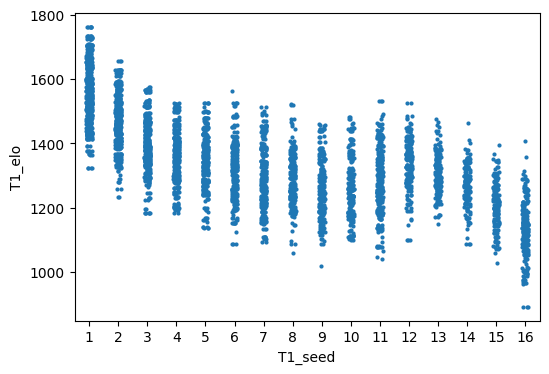

In [25]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

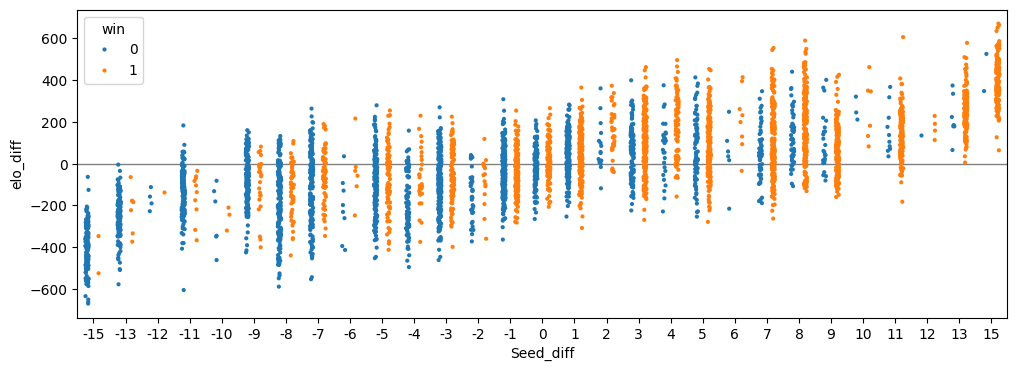

In [26]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
plt.axhline(y=0, color='gray', lw=1)

## Features — Tier 5: GLM Team Quality Score

In [27]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

ModuleNotFoundError: No module named 'statsmodels'

<Axes: ylabel='T1_quality'>

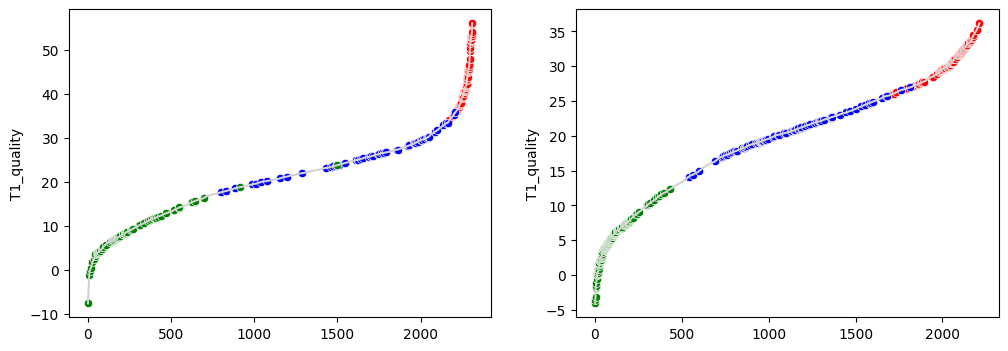

In [ ]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

In [ ]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,75,45,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,49,42,20,5,4,2,0,0,0,0,0,0,0,0,0
3,6,16,33,30,26,16,5,3,0,4,1,0,0,0,0,0
4,5,15,22,25,18,21,19,9,3,2,1,0,0,0,0,0
5,0,6,14,25,20,19,22,14,7,4,7,2,0,0,0,0
6,1,3,7,13,23,29,14,19,10,10,6,4,1,0,0,0
7,0,2,3,6,18,12,19,22,22,14,12,8,2,0,0,0
8,0,0,3,6,6,17,19,20,19,22,15,6,7,0,0,0
9,0,2,0,6,10,7,12,17,25,24,19,11,5,1,1,0


In [ ]:
from sklearn.metrics import roc_auc_score

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.807
Quality AUC : 0.825


In [ ]:
# seed vs. GLM quality: which one called it better each year?
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

## Model Training — XGBoost + Leave-One-Season-Out CV

In [ ]:
features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    # NEW: recent form & matchup history (from gold-medal solution logic)
    "T1_WinRatio14d",   # last-14-day win rate — captures tournament-entry form
    "T2_WinRatio14d",
    "T1_awins",         # full-season win ratio
    "T2_awins",
    "laplace_matchup",  # head-to-head history with Laplace smoothing
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",    
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
    ### MASSEY ORDINALS (men's only, NaN for women — XGBoost handles natively) ###
    "T1_MasseyRank",    # avg pre-tournament rank across all systems (lower = better)
    "T2_MasseyRank",
    "MasseyRank_diff",  # T2_rank - T1_rank: positive = T1 is better
]

print(f"Number of features: {len(features)}")

In [ ]:
import xgboost as xgb

# Using Cauchy loss instead of MSE
# MSE punishes big errors heavily — but in basketball, blowouts happen for random reasons
# and we don't want those outlier games to dominate training.
# Cauchy has heavier tails, so the model is more robust to lopsided scores.
def cauchyobj(preds, dtrain):
    labels = dtrain.get_label()
    c = 5000
    x = preds - labels
    x2 = x ** 2
    c2 = c ** 2
    grad = x / (x2 / c2 + 1)
    hess = -c2 * (x2 - c2) / (x2 + c2) ** 2
    return grad, hess

param = {}
param["booster"] = "gbtree"
param["eta"] = 0.02
param["subsample"] = 0.35
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 10
param["min_child_weight"] = 40
param["max_depth"] = 4
param["gamma"] = 10
param["tree_method"] = "hist"
param["grow_policy"] = "lossguide"
param["max_bin"] = 32

num_rounds = 400

In [ ]:
from sklearn.metrics import mean_absolute_error, brier_score_loss

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season-out cross validation
# each season acts as the holdout set once — avoids time leakage
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round=num_rounds,
        obj=cauchyobj,   # ← Cauchy loss replaces MSE
    )
    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"\naverage mae: {np.mean(oof_mae)}")

In [ ]:
df = pd.DataFrame(
    {"Season": oof_ss, "pred": oof_preds, "label": [(t > 0) * 1 for t in oof_targets], "men_women": tourney_data["men_women"]}
)
df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = df.clip(-30, 30).groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_women = df.clip(-30, 30).loc[df["men_women"] == 0].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_men = df.clip(-30, 30).loc[df["men_women"] == 1].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])

brier: 0.16783915781682182


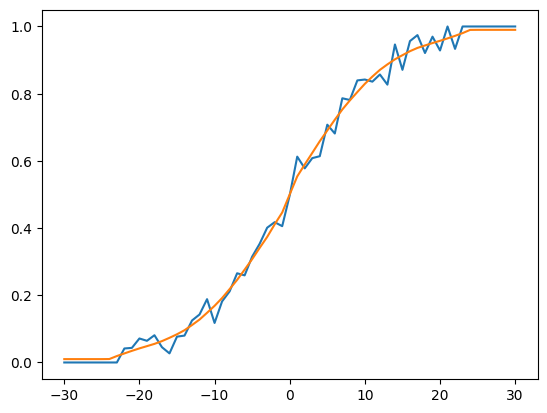

In [ ]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

In [ ]:
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    print(oof_season, np.round(brier_score_loss(y, x),5))

brier: 0.16783915781682182
2003 0.18084
2004 0.17125
2005 0.1682
2006 0.19143
2007 0.14185
2008 0.15584
2009 0.16436
2010 0.16328
2011 0.17982
2012 0.1529
2013 0.1758
2014 0.17581
2015 0.14193
2016 0.17511
2017 0.15895
2018 0.17967
2019 0.14183
2021 0.17853
2022 0.18682
2023 0.18363
2024 0.1555


## Final Step — Generate Submission

In [ ]:
# build all possible 2025 matchup pairs to predict
# (SampleSubmissionStage2.csv not available locally, so generating manually)
all_teams_2025 = sorted(set(
    regular_data.loc[regular_data["Season"] == 2025, "T1_TeamID"].unique().tolist()
))
from itertools import combinations
pairs = list(combinations(all_teams_2025, 2))
X = pd.DataFrame({"ID": [f"2025_{int(t1)}_{int(t2)}" for t1, t2 in pairs], "Pred": 0.5})
X

In [ ]:
# parse team IDs and attach all features to the submission frame
X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0]=='1' else 0)  # 1=men, 0=women

# season stats
X = pd.merge(X, ss_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, ss_T2, on=['Season', 'T2_TeamID'], how='left')
# seeds
X = pd.merge(X, seeds_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, seeds_T2, on=['Season', 'T2_TeamID'], how='left')
# GLM quality
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
# ELO
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

# late-season form + win ratio + head-to-head
X = pd.merge(X, late_T1, on=["Season","T1_TeamID"], how="left")
X = pd.merge(X, late_T2, on=["Season","T2_TeamID"], how="left")
X = pd.merge(X, awins_T1, on=["Season","T1_TeamID"], how="left")
X = pd.merge(X, awins_T2, on=["Season","T2_TeamID"], how="left")
X["laplace_matchup"] = X.apply(
    lambda r: laplace_matchup(r["Season"], r["T1_TeamID"], r["T2_TeamID"]), axis=1
)

# Massey Ordinals features (men's only)
X = pd.merge(X, massey_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, massey_T2, on=["Season", "T2_TeamID"], how="left")
X["MasseyRank_diff"] = X["T2_MasseyRank"] - X["T1_MasseyRank"]

In [ ]:
# run all models on the submission set, then average their predictions
preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest) * 1.0  # >1 = aggressive, <1 = conservative
    probs = np.clip(spline_model(np.clip(margin_preds, -t, t)), 0.01, 0.99)
    preds.append(probs)
X['Pred'] = np.array(preds).mean(axis=0)

In [ ]:
# clip extreme probabilities to avoid log-loss blowup on overconfident predictions
X['Pred'] = X['Pred'].clip(0.01, 0.99).round(6)

In [ ]:
X[['ID','Pred']].to_csv('/Users/ziqiwei/Downloads/predictions.csv', index=None)
print(f"Saved {len(X)} predictions to /Users/ziqiwei/Downloads/predictions.csv")